# Refraction correction on multi-frequency FITS

Uses `lwasolarutl.refraction_corr` (ported from [ovro-lwa-solar `refraction_correction.py`](https://github.com/ovro-eovsa/ovro-lwa-solar/blob/b55f56d5/ovrolwasolar/refraction_correction.py)).

Demo file: `../demofile/recovered_from_hdf.fits` (recover from HDF in `image_plot_hdf.ipynb` if missing).

1. **Fit** refraction coefficients `px`, `py`
2. **Save** coefficients into a copy of the FITS
3. **Apply** pixel shifts → level 1.5 FITS

```bash
pip install git+https://github.com/ovro-eovsa/lwa-solar-util.git
```


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import lwasolarutl as lsu

REPO = Path("..").resolve() if (Path("..") / "demofile").exists() else Path(".").resolve()
DEMO = REPO / "demofile"
FITS_IN = DEMO / "recovered_from_hdf.fits"
FITS_WITH_COEFF = DEMO / "recovered_with_refra_coeff.fits"
FITS_LEV15 = DEMO / "recovered_lev1.5.fits"

print("Input FITS:", FITS_IN)
print("Exists:", FITS_IN.exists())
if not FITS_IN.exists():
    raise FileNotFoundError(
        f"{FITS_IN} not found — run notebook/image_plot_hdf.ipynb to recover HDF → FITS"
    )


Input FITS: /fast/peijinz/lwa-solar-util/demofile/recovered_from_hdf.fits
Exists: True


## 1. Per-channel peaks vs fit gates

The fit uses channels with frequency > 45 MHz and peak Tb **below** `overbright` (default 2×10⁶ K) to exclude flares. The demo cube has peaks up to ~5×10⁶ K, so the default can leave too few channels. Inspect peaks, then choose `overbright` (or `overbright=None` to disable the cut).

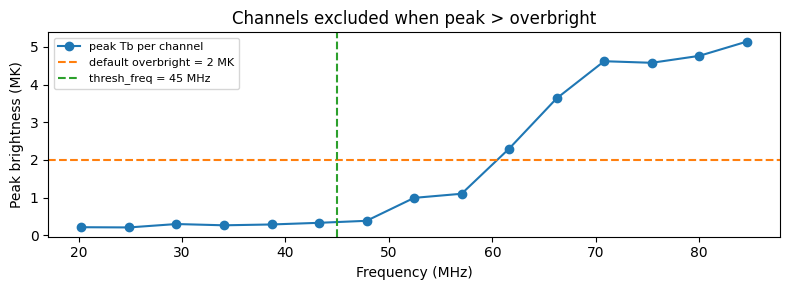

Using overbright = 5.40 MK
px: [ 9.47242509e+17 -1.69425238e+02]
py: [-9.59037960e+17  1.60727195e+02]
record: {'Time': '2026-05-14T20:00:01', 'px0': np.float64(9.472425094502636e+17), 'px1': np.float64(-169.42523798881493), 'py0': np.float64(-9.590379598398659e+17), 'py1': np.float64(160.72719453009543)}


In [2]:
diag = lsu.refraction_corr.refraction_fit_param(str(FITS_IN), return_full_data=True)
freqs_mhz = diag["freqs"] / 1e6
peaks_k = diag["peak_values"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(freqs_mhz, peaks_k / 1e6, "o-", label="peak Tb per channel")
ax.axhline(2.0, color="C1", ls="--", label="default overbright = 2 MK")
ax.axvline(45.0, color="C2", ls="--", label="thresh_freq = 45 MHz")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Peak brightness (MK)")
ax.legend(loc="best", fontsize=8)
ax.set_title("Channels excluded when peak > overbright")
plt.tight_layout()
plt.show()

# Include all channels above 45 MHz for this bright snapshot
mask_hi = diag["freqs"] > 45e6
OVERBRIGHT = float(np.nanmax(peaks_k[mask_hi]) * 1.05)
print(f"Using overbright = {OVERBRIGHT/1e6:.2f} MK")

px, py = lsu.refraction_corr.refraction_fit_param(
    str(FITS_IN), overbright=OVERBRIGHT
)
print("px:", px)
print("py:", py)

record = lsu.refraction_corr.refraction_fit_param(
    str(FITS_IN), overbright=OVERBRIGHT, return_record=True
)
print("record:", record)


## 2. Save coefficients (header + table columns, data unchanged)

In [3]:
lsu.refraction_corr.save_refraction_fit_param(
    str(FITS_IN), str(FITS_WITH_COEFF), px, py
)
print("Wrote", FITS_WITH_COEFF)


FITS file successfully updated.
Wrote /fast/peijinz/lwa-solar-util/demofile/recovered_with_refra_coeff.fits


## 3. Apply correction (level 1.0 → 1.5)

In [4]:
out = lsu.refraction_corr.apply_refra_coeff(
    str(FITS_IN), px, py, fname_out=str(FITS_LEV15), verbose=True
)
print("Output:", out)


FITS file successfully updated.
Output: /fast/peijinz/lwa-solar-util/demofile/recovered_lev1.5.fits


## 4. Compare one channel (before / after)

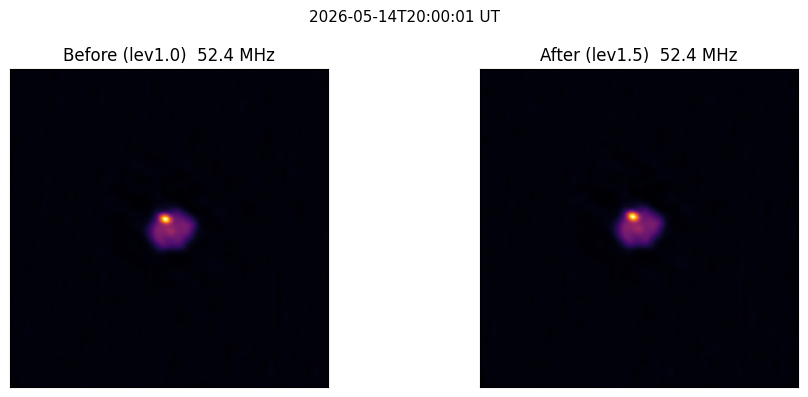

In [5]:
meta0, data0 = lsu.ndfits.read(str(FITS_IN))
meta1, data1 = lsu.ndfits.read(str(FITS_LEV15))
ch = len(meta0["ref_cfreqs"]) // 2
freq_mhz = meta0["ref_cfreqs"][ch] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, dat, title in zip(
    axes,
    [np.squeeze(data0[0, ch]), np.squeeze(data1[0, ch])],
    ["Before (lev1.0)", "After (lev1.5)"],
):
    ax.imshow(dat, origin="lower", cmap="inferno")
    ax.set_title(f"{title}  {freq_mhz:.1f} MHz")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(meta0["header"]["date-obs"][:19] + " UT", fontsize=11)
plt.tight_layout()
plt.show()


## 5. Default 12-panel layout (before / after)

OVRO-LWA 3×4 grid at 12 standard frequencies (`slow_pipeline_default_plot`), same as `image_plot_hdf.ipynb`.

Before — level 1.0: recovered_from_hdf.fits


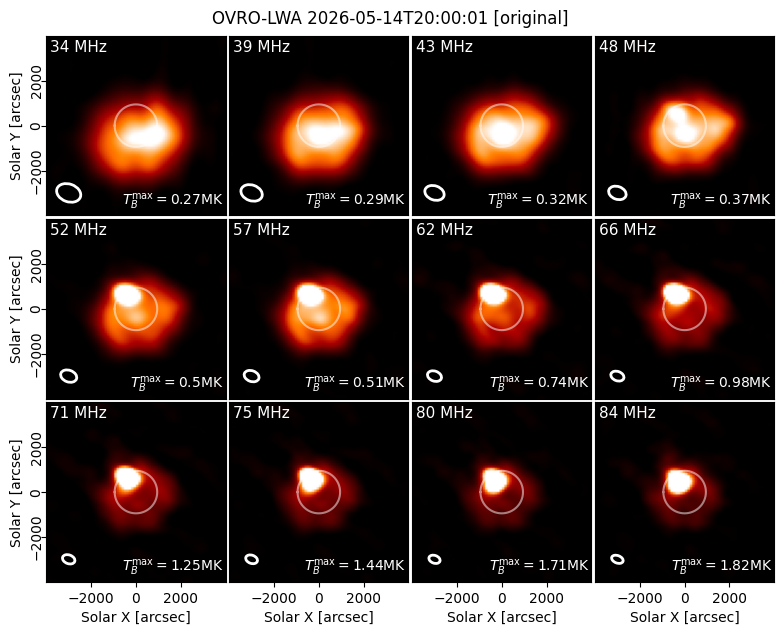

After — level 1.5: recovered_lev1.5.fits


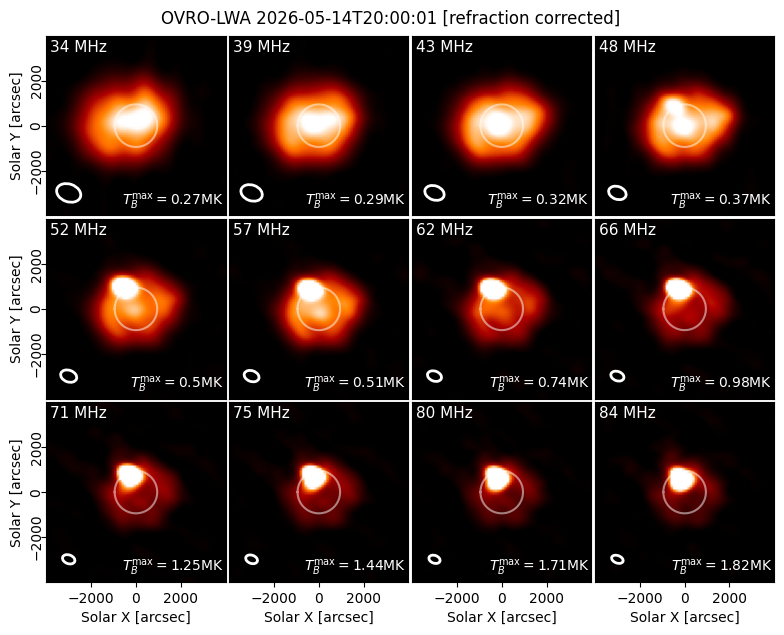

In [6]:
print("Before — level 1.0:", FITS_IN.name)
fig_before, _ = lsu.visualization.slow_pipeline_default_plot(
    str(FITS_IN),
    add_logo=False,
)
plt.show()

print("After — level 1.5:", FITS_LEV15.name)
fig_after, _ = lsu.visualization.slow_pipeline_default_plot(
    str(FITS_LEV15),
    add_logo=False,
)
plt.show()